# ĐỒ ÁN 2: DATA FITTING VÀ PHƯƠNG PHÁP OLS
### PHẦN 1: Lý Thuyết Data Fitting và Minh Họa

* **Môn học:** Toán Ứng Dụng và Thống Kê
* **Mã môn:** MTH00051
* **Học kỳ:** Học kỳ 2, Năm học 2025 - 2026
* **Giảng viên lý thuyết:** ThS. Võ Nam Thục Đoan, ThS. Lê Nhựt Nam
* **Nhóm thực hiện:** Nhóm 14

---

**Mục tiêu:**

Đồ án này tập trung vào việc nghiên cứu và tự cài đặt thuật toán Ordinary Least Squares (OLS) nhằm giải quyết bài toán Data Fitting. Các mục tiêu cốt lõi bao gồm:

1.  **Hiểu bản chất toán học:** Nắm vững nền tảng lý thuyết Data Fitting và phương pháp OLS, giải quyết hệ phương trình chuẩn để tìm nghiệm $\hat{\beta} = (X^T X)^{-1} X^T y$.
2.  **Cài đặt OLS từ gốc (from scratch):** Tự xây dựng thuật toán OLS sử dụng các phép toán đại số tuyến tính cơ bản, không phụ thuộc vào thư viện có sẵn.
3.  **Thực hiện suy diễn thống kê:** Tính toán và diễn giải các chỉ số thống kê quan trọng (Standard Error, t-statistic, p-value, Confidence Interval) để đánh giá mức độ đóng góp của từng biến.
4.  **Đánh giá mô hình:** Sử dụng các độ đo tiêu chuẩn (MSE, RMSE, $R^2$) để đo lường hiệu suất mô hình và trực quan hóa kết quả.
5.  **Nhận diện hạn chế của OLS:** Phân tích vấn đề đa cộng tuyến (Multicollinearity), tạo tiền đề cho việc nghiên cứu các mô hình điều chuẩn (Regularization) như Ridge và Lasso ở phần tiếp theo.

## 1. Khởi tạo môi trường và Import các hàm tiện ích

In [1]:
import os
import sys
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import r2_score
from scipy import stats
from sklearn.linear_model import LinearRegression 
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm
from sklearn.linear_model import Ridge, RidgeCV, Lasso

RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (8, 5)

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))
from utils import make_linear_data, make_multifeature_data, make_collinear_data

from ols_implementation import (
    ols_fit, 
    hat_matrix, 
    model_metrics, 
    coef_inference, 
    vif
)
from ridge_lasso import (
    ridge_fit, 
    lasso_fit, 
    ridge_trace, 
    lasso_trace, 
    make_lambda_grid
)
from residual_analysis import residual_diagnostics
from cross_validation import kfold_cv, select_lambda_cv
from gauss_markov_demo import run_gauss_markov_simulation

print("Thiết lập môi trường thực nghiệm thành công")

Thiết lập môi trường thực nghiệm thành công


## 2. Ordinary Least Squares (OLS)

### 2.1. Cơ sở lý thuyết
Mô hình hồi quy tuyến tính có dạng:
$$y = X\beta + \epsilon$$

Trong đó:
* $X$ là ma trận đặc trưng kích thước $n \times (p+1)$ (đã bao gồm cột bias chứa toàn số 1).
* $y$ là vector mục tiêu kích thước $n \times 1$.
* $\beta$ là vector hệ số hồi quy kích thước $(p+1) \times 1$.
* $\epsilon$ là vector sai số ngẫu nhiên.

Mục tiêu của thuật toán OLS là tìm ra bộ trọng số $\hat{\beta}$ sao cho **Tổng bình phương phần dư (RSS - Residual Sum of Squares)** là nhỏ nhất. Thông qua việc lấy đạo hàm hàm mất mát và giải phương trình, ta thu được hệ phương trình chuẩn (**Normal Equations**):
$$(X^T X)\hat{\beta} = X^T y$$

Nghiệm giải tích đóng (closed-form solution) để tìm $\hat{\beta}$ là:
$$\hat{\beta} = (X^T X)^{-1} X^T y$$

Sau khi có $\hat{\beta}$, ước lượng phương sai của nhiễu $\hat{\sigma}^2$ được tính bằng:
$$\hat{\sigma}^2 = \frac{RSS}{n - p - 1}$$

### 2.2. Thực nghiệm

In [2]:
X_ols, y_ols, TRUE_BETA_OLS = make_linear_data(n=50, sigma=0.5, seed=RANDOM_STATE)

print("--- THÔNG TIN TÓM TẮT DATASET TUYẾN TÍNH GIẢ LẬP ---")
print(f"• Kích thước X (Features): {len(X_ols)} dòng, {len(X_ols[0])} cột")
print(f"• Kích thước y (Target)  : {len(y_ols)} phần tử")
print(f"• Vector hệ số thực (True Beta): {TRUE_BETA_OLS} (Intercept, Beta_1, Beta_2)")

df_preview = pd.DataFrame(X_ols, columns=[f'Feature_x{i+1}' for i in range(len(X_ols[0]))])
df_preview.insert(0, 'Intercept_Column', 1.0) 
df_preview['Target_y'] = y_ols

print("\n--- BẢNG XEM TRƯỚC 5 MẪU DỮ LIỆU ĐẦU TIÊN ---")
display(df_preview.head(5))
print("-" * 75)

res_ols = ols_fit(X_ols, y_ols)
print("--- KẾT QUẢ TỪ HÀM OLS TỰ CÀI ĐẶT ---")
print(f"Beta hat: {res_ols['beta_hat']}")
print(f"Sigma^2 hat: {res_ols['sigma2_hat']:.4f}\n")

X_arr = np.array(X_ols)
y_arr = np.array(y_ols)

sk_model = LinearRegression()
sk_model.fit(X_arr, y_arr)

beta_hat_sklearn = [sk_model.intercept_] + sk_model.coef_.tolist()

p_features = len(beta_hat_sklearn) - 1
coef_labels = ['Intercept'] + [f'Beta_{i}' for i in range(1, p_features + 1)]

df_compare = pd.DataFrame({
    'Hệ số': coef_labels,
    'beta_hat (ols_fit)': res_ols['beta_hat'],
    'beta_hat (sklearn)': beta_hat_sklearn
})

df_compare['Sai số tương đối'] = np.abs(df_compare['beta_hat (ols_fit)'] - df_compare['beta_hat (sklearn)']) / (np.abs(df_compare['beta_hat (sklearn)']) + 1e-15)

print("--- KIỂM CHỨNG KẾT QUẢ VỚI SCIKIT-LEARN ---")
display(df_compare)

max_err = df_compare['Sai số tương đối'].max()
if max_err < 1e-10:
    print(f"=> Kết luận: Thuật toán tự cài đặt hoàn toàn chính xác (Sai số lớn nhất: {max_err:.2e})")
else:
    print(f"=> Cảnh báo: Có sự chênh lệch lớn (Sai số lớn nhất: {max_err:.2e})")

--- THÔNG TIN TÓM TẮT DATASET TUYẾN TÍNH GIẢ LẬP ---
• Kích thước X (Features): 50 dòng, 2 cột
• Kích thước y (Target)  : 50 phần tử
• Vector hệ số thực (True Beta): [1.0, 2.0] (Intercept, Beta_1, Beta_2)

--- BẢNG XEM TRƯỚC 5 MẪU DỮ LIỆU ĐẦU TIÊN ---


,Intercept_Column,Feature_x1,Feature_x2,Target_y
0,1.0,2.788536,-9.499785,-16.266692
1,1.0,4.729424,3.533990,12.148396
2,1.0,7.843591,-8.261223,-8.787335
3,1.0,-5.627241,0.107106,-5.355087
4,1.0,-9.469281,-6.023247,-21.884935


---------------------------------------------------------------------------
--- KẾT QUẢ TỪ HÀM OLS TỰ CÀI ĐẶT ---
Beta hat: [-0.024615801172231278, 0.9958153622868547, 2.0192644669098265]
Sigma^2 hat: 0.2167

--- KIỂM CHỨNG KẾT QUẢ VỚI SCIKIT-LEARN ---


,Hệ số,beta_hat (ols_fit),beta_hat (sklearn),Sai số tương đối
0,Intercept,-0.024616,-0.024616,4.510205e-14
1,Beta_1,0.995815,0.995815,3.344665e-16
2,Beta_2,2.019264,2.019264,4.398524e-16


=> Kết luận: Thuật toán tự cài đặt hoàn toàn chính xác (Sai số lớn nhất: 4.51e-14)


## 3. Phân tích Ma trận chiếu Hat Matrix
### 3.1. Cơ sở lý thuyết
Ma trận mũ (Hat Matrix) $\mathbf{H}$ đóng vai trò là toán tử chiếu tuyến tính không gian vector mục tiêu $\mathbf{y}$ sang vector giá trị dự báo $\hat{\mathbf{y}}$:
$$\hat{\mathbf{y}} = \mathbf{X}\hat{\boldsymbol{\beta}} = \mathbf{X}(\mathbf{X}^T \mathbf{X})^{-1}\mathbf{X}^T \mathbf{y} = \mathbf{H}\mathbf{y}$$
$$\mathbf{H} = \mathbf{X}(\mathbf{X}^T \mathbf{X})^{-1}\mathbf{X}^T$$

Từ đó, toán tử chiếu phần dư (Residual Maker Matrix) được xác định thông qua ma trận đơn vị $\mathbf{I}$ là $(\mathbf{I} - \mathbf{H})$, giúp biểu diễn phần dư $\hat{\boldsymbol{\epsilon}}$ một cách trực giao:
$$\hat{\boldsymbol{\epsilon}} = \mathbf{y} - \hat{\mathbf{y}} = \mathbf{y} - \mathbf{H}\mathbf{y} = (\mathbf{I} - \mathbf{H})\mathbf{y}$$

**Các thuộc tính hình học toán học cốt lõi:**
1. **Tính đối xứng (Symmetric):** $\mathbf{H} = \mathbf{H}^T$ và $(\mathbf{I} - \mathbf{H}) = (\mathbf{I} - \mathbf{H})^T$.
2. **Tính lũy đẳng (Idempotent):** $\mathbf{H}^2 = \mathbf{H}$ và $(\mathbf{I} - \mathbf{H})^2 = (\mathbf{I} - \mathbf{H})$. Ý nghĩa hình học: Phép chiếu trùng lặp nhiều lần lên cùng một không gian không làm thay đổi vị trí vector kết quả.
3. **Giá trị riêng (Eigenvalues):** Các giá trị riêng của ma trận chiếu trực giao $\mathbf{H}$ và $(\mathbf{I} - \mathbf{H})$ chỉ nhận giá trị $0$ hoặc $1$.
4. **Hạng:** $$\text{Rank}(\mathbf{H}) =  p + 1$$


### 3.2. Thực nghiệm

--- DỮ LIỆU ĐẦU VÀO: 15 mẫu, 2 đặc trưng ---


,Thuộc tính toán học,Trạng thái kiểm chứng
0,Idempotent (H² = H),True
1,Symmetric (H = Hᵀ),True
2,Hạng ma trận (Rank),3


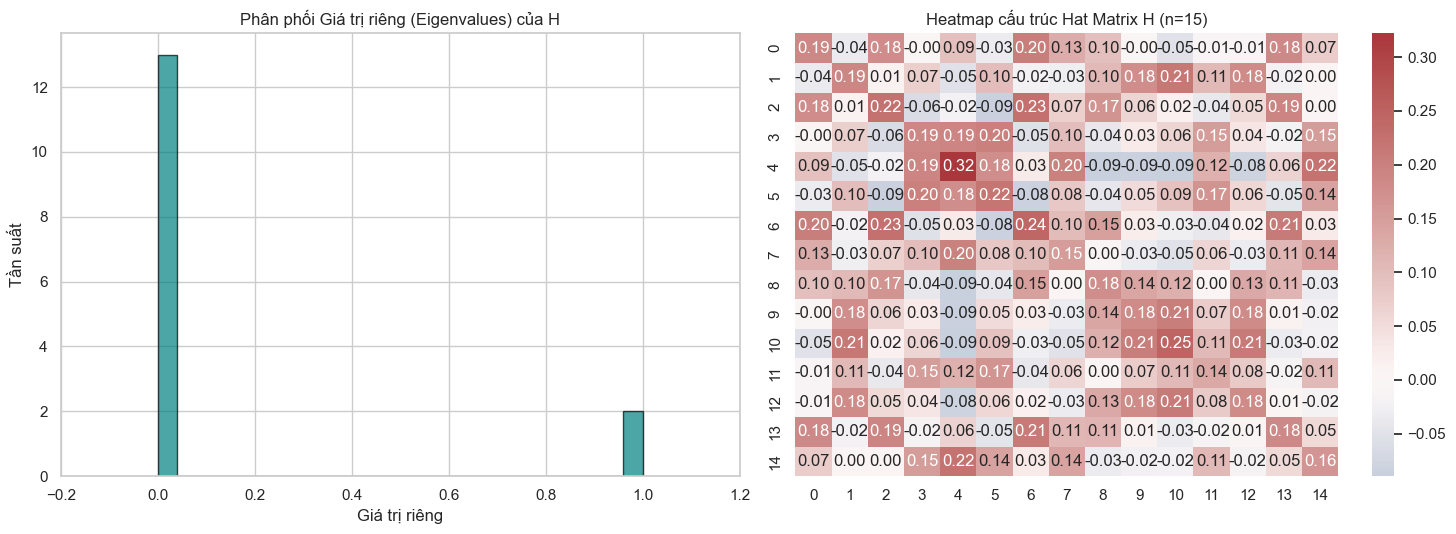

In [3]:
X_small, _, _ = make_multifeature_data(n=15, p=2, sigma=0.5, seed=RANDOM_STATE)

print(f"--- DỮ LIỆU ĐẦU VÀO: {len(X_small)} mẫu, {len(X_small[0])} đặc trưng ---")

res_hat = hat_matrix(X_small)
H_matrix = np.array(res_hat['H'])

df_properties = pd.DataFrame({
    'Thuộc tính toán học': ['Idempotent (H² = H)', 'Symmetric (H = Hᵀ)', 'Hạng ma trận (Rank)'],
    'Trạng thái kiểm chứng': [res_hat['is_idempotent'], res_hat['is_symmetric'], res_hat['rank']]
})
display(df_properties)

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

axes[0].hist(res_hat['eigenvalues'], bins=25, color='teal', edgecolor='black', alpha=0.7)
axes[0].set_title('Phân phối Giá trị riêng (Eigenvalues) của H')
axes[0].set_xlabel('Giá trị riêng')
axes[0].set_ylabel('Tần suất')
axes[0].set_xlim(-0.2, 1.2)

sns.heatmap(H_matrix, ax=axes[1], cmap='vlag', center=0, annot=True, fmt=".2f", cbar=True)
axes[1].set_title('Heatmap cấu trúc Hat Matrix H (n=15)')

plt.tight_layout()
plt.show()

### 3.3. Nhận xét và Phân tích kết quả
Kết quả kiểm chứng ma trận Hat ($H$) cho thấy mô hình đã cài đặt chính xác các tính chất toán học cơ bản:

* **Tính Idempotent ($H^2 = H$):** Kết quả trả về `True` xác nhận ma trận $H$ là toán tử chiếu. Việc chiếu một vector hai lần cũng cho kết quả tương đương với việc chiếu một lần duy nhất.
* **Tính Đối xứng ($H = H^T$):** Kết quả `True` và Heatmap cho thấy các phần tử đối xứng qua đường chéo chính có giá trị bằng nhau, khẳng định ma trận $H$ là ma trận đối xứng.
* **Giá trị riêng (Eigenvalues):** Histogram cho thấy các giá trị riêng chỉ tập trung tại 0 và 1 (với số lượng giá trị riêng bằng 1 đúng bằng rank của ma trận là 3). Đây là đặc trưng nhận dạng của một ma trận chiếu (projection matrix).
* **Hạng ma trận (Rank):** Kết quả bằng 3 (đúng bằng $p+1$ với $p=2$ biến độc lập) xác nhận ma trận $H$ chiếu dữ liệu $y$ vào một không gian con 3 chiều (gồm 2 chiều của features và 1 chiều của intercept).

## 4. Các Chỉ Số Đo Lường Hiệu Năng Mô Hình
### 4.1. Cơ sở lý thuyết
Đánh giá mức độ phù hợp của đường hồi quy tuyến tính thực nghiệm thông qua phân rã tổng bình phương và các độ đo sai số:

- **TSS (Total Sum of Squares):** Tổng bình phương toàn bộ độ lệch của dữ liệu thực tế so với giá trị trung bình.
$$TSS = \sum_{i=1}^{n} (y_i - \bar{y})^2$$

- **RSS (Residual Sum of Squares):** Tổng bình phương sai số phần dư (phần biến thiên không giải thích được).
$$RSS = \sum_{i=1}^{n} (y_i - \hat{y}_i)^2 = \sum_{i=1}^{n} \hat{\epsilon}_i^2$$

- **MSS (Model Sum of Squares):** Tổng bình phương độ lệch được giải thích bởi mô hình.
$$MSS = \sum_{i=1}^{n} (\hat{y}_i - \bar{y})^2$$

- **$R^2$ (Coefficient of Determination):** Tỷ lệ biến thiên của tập dữ liệu được giải thích bởi mô hình hồi quy.
$$R^2 = 1 - \frac{RSS}{TSS} = \frac{MSS}{TSS}$$

- **$R^2$ hiệu chỉnh (Adjusted $R^2$):** Phiên bản hiệu chỉnh của $R^2$, dùng để phạt mô hình khi thêm các biến độc lập không có ý nghĩa thống kê (với $n$ là số quan sát, $p$ là số biến độc lập).
$$\overline{R}^2 = 1 - (1 - R^2)\frac{n-1}{n-p-1}$$

- **Kiểm định F tổng thể (F-statistic):** Đánh giá giả thuyết $H_0: \beta_1 = \beta_2 = ... = \beta_p = 0$ (mô hình không có ý nghĩa).
$$F = \frac{MSS / p}{RSS / (n - p - 1)}$$

- **MAE (Mean Absolute Error):** Trung bình trị tuyệt đối sai số dự báo, giúp đánh giá sai số trung bình mà không bị phạt quá nặng bởi các điểm dị biệt (outliers).
$$MAE = \frac{1}{n} \sum_{i=1}^{n} |y_i - \hat{y}_i|$$

- **RMSE (Root Mean Squared Error):** Căn bậc hai của trung bình bình phương sai số. Do bị lấy bình phương trước khi tính trung bình, RMSE nhạy cảm hơn với các sai số lớn.
$$RMSE = \sqrt{\frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2}$$

### 4.2. Thực nghiệm

In [4]:
metrics_res = model_metrics(y_ols, res_ols['y_hat'], p=2)
r2_sklearn = r2_score(y_ols, res_ols['y_hat'])

print("--- THỐNG KÊ HIỆU NĂNG VÀ KIỂM ĐỊNH F TỔNG THỂ ---")

df_metrics = pd.DataFrame({
    'Chỉ số': list(metrics_res.keys()),
    'Giá trị': list(metrics_res.values())
})
df_metrics.index = range(1, len(df_metrics) + 1)

display(df_metrics)

print(f"\n--- KIỂM CHỨNG R² ---")
print(f"R² (Tự cài đặt)   : {metrics_res['R2']:.6f}")
print(f"R² (Scikit-Learn) : {r2_sklearn:.6f}")

if np.isclose(metrics_res['R2'], r2_sklearn):
    print("=> Kết luận: Giá trị R² khớp với thư viện chuẩn!")
else:
    print("=> Cảnh báo: Có sự chênh lệch nhỏ trong tính toán R².")

--- THỐNG KÊ HIỆU NĂNG VÀ KIỂM ĐỊNH F TỔNG THỂ ---


,Chỉ số,Giá trị
1,RSS,1.018448e+01
2,TSS,9.259046e+03
3,MSS,9.248862e+03
4,R2,9.989001e-01
5,R2_adj,9.988532e-01
6,F_stat,2.134113e+04
7,F_pvalue,2.966568e-70
8,MAE,3.611871e-01
9,RMSE,4.513198e-01



--- KIỂM CHỨNG R² ---
R² (Tự cài đặt)   : 0.998900
R² (Scikit-Learn) : 0.998900
=> Kết luận: Giá trị R² khớp với thư viện chuẩn!


## 5. Suy Diễn Thống Kê và Khoảng Tin Cậy Cho Hệ Số
### 5.1. Cơ sở lý thuyết
Dưới giả thuyết sai số phân phối chuẩn độc lập đồng phương sai, ước lượng hệ số tuân theo phân phối chuẩn đa biến. Kiểm định ý nghĩa thống kê của từng biến đặc trưng ($H_0: \beta_j = 0$) qua thống kê t-Student:
$$t_j = \frac{\hat{\beta}_j}{se(\hat{\beta}_j)} \sim t_{n-p-1}$$
Nếu $P(|t| > t_j) < 0.05$, ta bác bỏ giả thuyết $H_0$ và kết luận đặc trưng đó có ý nghĩa tác động lên biến mục tiêu.

### 5.2. Thực nghiệm

In [ ]:
res_ols_inf = ols_fit(X_ols, y_ols)

beta_hat_inf = res_ols_inf["beta_hat"]
sigma2_inf = res_ols_inf["sigma2_hat"]
result_inf = coef_inference(X_ols, y_ols, beta_hat=beta_hat_inf, sigma2=sigma2_inf)
df_inference = pd.DataFrame(result_inf).set_index('index')

def highlight_sig(val):
    if isinstance(val, (int, float)) and val < 0.05:
        return 'font-weight: bold'
    return ''

print("--- 1. BẢNG CHI TIẾT THỐNG KÊ SUY DIỄN HỆ SỐ ---")
styled_df = df_inference.style.map(highlight_sig, subset=['p_value'])
display(styled_df)

print("\n--- 2. KIỂM CHỨNG BẰNG THƯ VIỆN STATSMODELS ---")
X_sm = sm.add_constant(X_ols)
model_sm = sm.OLS(y_ols, X_sm)
results_sm = model_sm.fit()

print(results_sm.summary().tables[1])

print("\n--- 3. BẢNG ĐỐI CHIẾU TRỰC TIẾP P-VALUE ---")
p_values_sm = np.array(results_sm.pvalues)
df_p_check = pd.DataFrame({
    'Hệ số': df_inference.index,
    'Tự cài đặt': df_inference['p_value'].values,
    'Statsmodels': p_values_sm,
    'Sai số tuyệt đối': np.abs(df_inference['p_value'].values - p_values_sm)
})
display(df_p_check.style.format({
    'Tự cài đặt': '{:.6f}', 
    'Statsmodels': '{:.6f}',
    'Sai số tuyệt đối': '{:.2e}'
}))

print("\n--- 4. KIỂM TRA SAI LỆCH TUYỆT ĐỐI ---")
max_diff = df_p_check['Sai số tuyệt đối'].max()

if max_diff < 1e-9:
    print(f"=> Kết luận: Thuật toán tự cài đặt hoàn toàn chính xác so với chuẩn thư viện (Sai lệch lớn nhất: {max_diff:.2e}).")
else:
    print(f"=> Cảnh báo: Có sự chênh lệch nhỏ trong tính toán (Sai lệch lớn nhất: {max_diff:.2e}).")

--- 1. BẢNG CHI TIẾT THỐNG KÊ SUY DIỄN HỆ SỐ ---


,coef,std_err,t_stat,p_value,ci_lower,ci_upper
intercept,-0.024616,0.066538,-0.369953,0.713079,-0.158472,0.109241
x1,0.995815,0.010273,96.933283,0.000000,0.975148,1.016482
x2,2.019264,0.011321,178.369712,0.000000,1.996490,2.042039



--- 2. KIỂM CHỨNG BẰNG THƯ VIỆN STATSMODELS ---
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0246      0.067     -0.370      0.713      -0.158       0.109
x1             0.9958      0.010     96.933      0.000       0.975       1.016
x2             2.0193      0.011    178.370      0.000       1.996       2.042

--- 3. BẢNG ĐỐI CHIẾU TRỰC TIẾP P-VALUE ---


,Hệ số,Tự cài đặt,Statsmodels,Sai số tuyệt đối
0,intercept,0.713079,0.713079,9.99e-15
1,x1,0.000000,0.000000,3.48e-69
2,x2,0.000000,0.000000,6.67e-82



--- 4. KIỂM TRA SAI LỆCH TUYỆT ĐỐI ---
=> Kết luận: Thuật toán tự cài đặt hoàn toàn chính xác so với chuẩn thư viện (Sai lệch lớn nhất: 9.99e-15).


## 6. Hệ Thống Chẩn Đoán Đồ Thị Phần Dư - Residual Analysis
### 6.1. Cơ sở lý thuyết
Xác thực độ tin cậy và tính hợp lệ của các giả thiết Gauss-Markov thông qua 4 biểu đồ trực quan hình học:
1. **Residuals vs Fitted:** Đánh giá tính tuyến tính và giả thiết phương sai đồng đều.
2. **Normal Q-Q Plot:** Kiểm chứng giả thiết phần dư tuân theo luật phân phối chuẩn.
3. **Scale-Location:** Phát hiện hiện tượng phương sai thay đổi (heteroscedasticity).
4. **Cook's Distance:** Định vị các điểm dữ liệu dị biệt có sức ảnh hưởng (influential outliers) phá vỡ tính bền vững của mô hình.

### 6.2. Thực nghiệm

--- DỮ LIỆU ĐỂ CHẨN ĐOÁN PHẦN DƯ (Nhiễu sigma=2.0) ---


,Feature_1,Feature_2
0,2.788536,-9.499785
1,4.729424,3.533990
2,7.843591,-8.261223


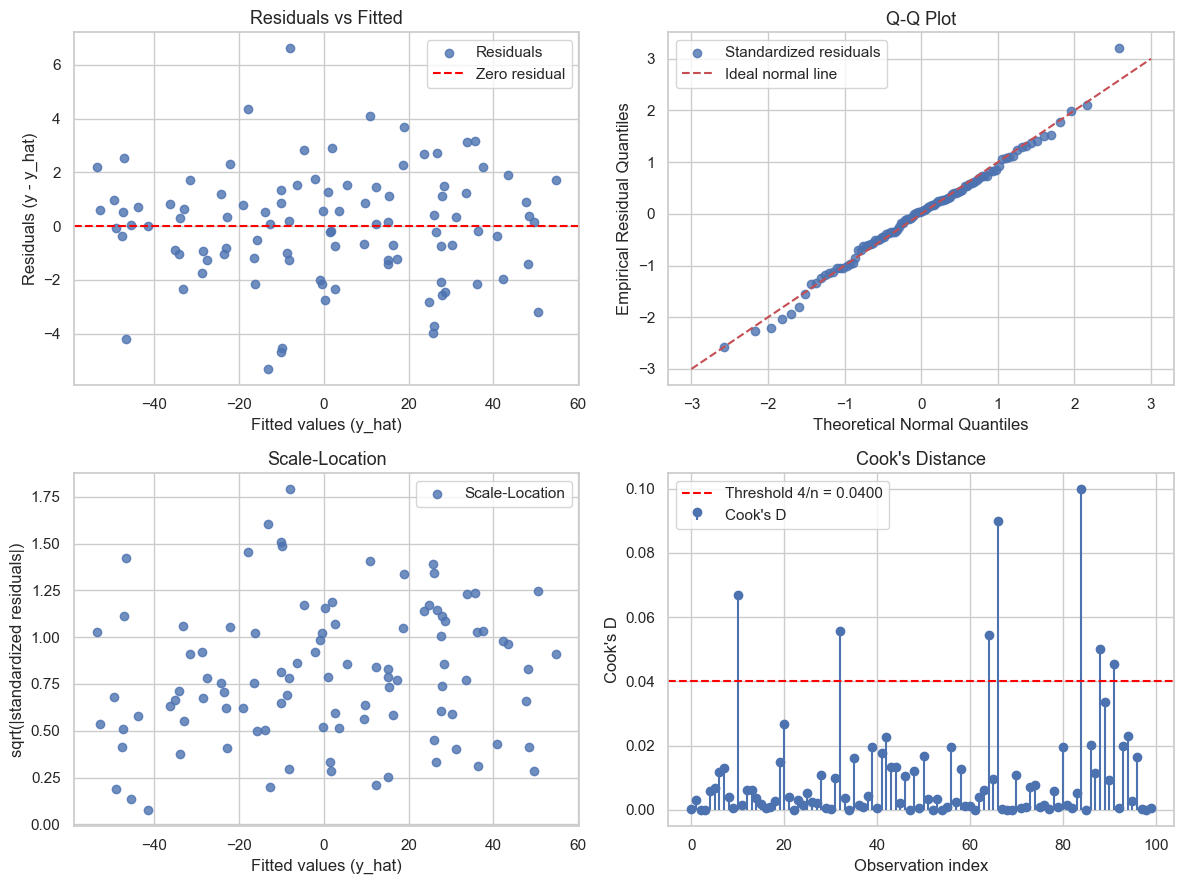

In [6]:
X_res, y_res, _= make_multifeature_data(n = 100, p = 2, sigma=2.0, seed=RANDOM_STATE)

print("--- DỮ LIỆU ĐỂ CHẨN ĐOÁN PHẦN DƯ (Nhiễu sigma=2.0) ---")
df_res = pd.DataFrame(X_res, columns=['Feature_1', 'Feature_2'])
display(df_res.head(3))

res_ols_diag = ols_fit(X_res, y_res)
y_hat_res = res_ols_diag["y_hat"]

fig_res, metrics_res = residual_diagnostics(
    y=y_res,
    y_hat=y_hat_res,
    X=X_res
);

**Nhận xét chẩn đoán phần dư (Residual Diagnostics):**

Dựa trên bốn biểu đồ chẩn đoán phần dư, có thể đánh giá mức độ phù hợp và độ tin cậy của mô hình hồi quy tuyến tính như sau:

1. **Residuals vs Fitted (Kiểm tra tính tuyến tính):** Các phần dư phân bố tương đối ngẫu nhiên quanh đường tham chiếu y=0, không xuất hiện xu hướng phi tuyến rõ rệt (như đường cong hay mô hình hệ thống). Điều này cho thấy giả định tuyến tính của mô hình nhìn chung được thỏa mãn.
2. **Normal Q-Q Plot (Kiểm tra phân phối chuẩn):** Hầu hết các điểm phân vị thực nghiệm nằm gần đường chuẩn lý thuyết, cho thấy phân phối của phần dư xấp xỉ chuẩn. Một số sai lệch nhỏ xuất hiện ở hai đầu đuôi nhưng chưa đủ mạnh để bác bỏ giả định phân phối chuẩn.
3. **Scale-Location (Kiểm tra tính đồng nhất phương sai - Homoscedasticity):** Biểu đồ Scale-Location không cho thấy hiện tượng hình phễu (funnel pattern) rõ ràng; độ phân tán của phần dư chuẩn hóa nhìn chung tương đối đồng đều theo fitted values. Điều này gợi ý giả định phương sai không đổi (homoscedasticity) được đáp ứng ở mức chấp nhận được.
4. **Cook's Distance (Kiểm tra điểm ảnh hưởng lớn - Influential points):** Một số quan sát có Cook’s Distance vượt ngưỡng kinh nghiệm 4/n, cho thấy tồn tại các điểm có mức ảnh hưởng tương đối lớn lên mô hình. Tuy nhiên, không có giá trị Cook’s Distance cực đoan (ví dụ gần 1), nên chưa có bằng chứng mạnh cho thấy mô hình bị chi phối nghiêm trọng bởi một vài quan sát đơn lẻ. Các quan sát này có thể được xem xét thêm trong các phân tích chuyên sâu nhằm đánh giá mức độ ảnh hưởng cụ thể đến kết quả mô hình.

## 7. Chẩn Đoán Hiện Tượng Đa Cộng Tuyến - Chỉ số VIF
### 7.1. Cơ sở lý thuyết
Đa cộng tuyến (Multicollinearity) xuất hiện khi tồn tại sự tương quan tuyến tính mạnh giữa các biến giải thích, khiến ma trận hồi quy $\mathbf{X}^T\mathbf{X}$ tiệm cận trạng thái suy biến, làm phóng đại phương sai sai số của hệ số. Chỉ số Phóng đại Phương sai (Variance Inflation Factor) của biến thứ $j$ được xác định qua:
$$VIF_j = \frac{1}{1 - R_j^2}$$
Trong đó $R_j^2$ thu được từ bài toán hồi quy phụ của biến đặc trưng $X_j$ theo toàn bộ các biến độc lập còn lại. Ngưỡng cảnh báo đa cộng tuyến nghiêm trọng khi $VIF_j > 10$.

### 7.2. Thực nghiệm

In [7]:
X_collinear, y_collinear = make_collinear_data(n=100, seed=RANDOM_STATE)

def highlight_vif(s):
    return ['font-weight: bold' if v > 10 else '' for v in s]

print("--- DỮ LIỆU ĐA CỘNG TUYẾN (x3 ≈ x1 + x2) ---")
df_collinear = pd.DataFrame(X_collinear, columns=['x1', 'x2', 'x3'])
display(df_collinear.head(3))

vif_custom = vif(X_collinear)

print("\n--- CHỈ SỐ VIF TỰ CÀI ĐẶT ---")
df_custom = pd.DataFrame({'VIF': vif_custom.values()}, index=vif_custom.keys())
display(df_custom.style.apply(highlight_vif))

print("\n--- KIỂM CHỨNG VỚI STATSMODELS ---")
X_arr = np.array(X_collinear)
X_sm = sm.add_constant(X_arr)
vif_sm = [variance_inflation_factor(X_sm, i+1) for i in range(X_arr.shape[1])]

df_vif_check = pd.DataFrame({
    'Tự cài đặt': vif_custom.values(),
    'Statsmodels': vif_sm
}, index=['x1', 'x2', 'x3'])

df_vif_check['Sai số'] = np.abs(df_vif_check['Tự cài đặt'] - df_vif_check['Statsmodels'])

display(df_vif_check)

max_diff = df_vif_check['Sai số'].max()
print(f"\n=> Kiểm chứng: Sai lệch lớn nhất là {max_diff:.2e}.")
if max_diff < 1e-9:
    print("=> Kết luận: Thuật toán VIF tự cài đặt hoàn toàn chính xác!")
else:
    print("=> Kết luận: Có sự chênh lệch nhỏ (do sai số làm tròn), nhưng thuật toán đạt yêu cầu.")

high_vif_vars = [idx for idx, val in vif_custom.items() if val > 10]
if high_vif_vars:
    print(f"=> Cảnh báo: Các biến {high_vif_vars} có VIF > 10, dấu hiệu đa cộng tuyến nghiêm trọng!")
else:
    print("=> Kết luận: Không phát hiện đa cộng tuyến nghiêm trọng (VIF < 10).")

--- DỮ LIỆU ĐA CỘNG TUYẾN (x3 ≈ x1 + x2) ---


,x1,x2,x3
0,2.788536,-9.499785,-6.712362
1,4.729424,3.533990,8.266737
2,-1.561564,-9.404056,-10.963296



--- CHỈ SỐ VIF TỰ CÀI ĐẶT ---


,VIF
x1,339530.855967
x2,307111.814530
x3,655087.709186



--- KIỂM CHỨNG VỚI STATSMODELS ---


,Tự cài đặt,Statsmodels,Sai số
x1,339530.855967,339530.855967,0.0
x2,307111.814530,307111.814530,0.0
x3,655087.709186,655087.709186,0.0



=> Kiểm chứng: Sai lệch lớn nhất là 0.00e+00.
=> Kết luận: Thuật toán VIF tự cài đặt hoàn toàn chính xác!
=> Cảnh báo: Các biến ['x1', 'x2', 'x3'] có VIF > 10, dấu hiệu đa cộng tuyến nghiêm trọng!


## 8. Hồi Quy Ridge & Đồ Thị Co Rút Hệ Số
### 8.1. Cơ sở lý thuyết
Phương pháp Ridge Regression ($L_2$) bổ sung thành phần phạt chuẩn $L_2$ ($\lambda \|\boldsymbol{\beta}\|_2^2$) vào hàm mất mát nhằm kiểm soát phương sai hệ số khi gặp đa cộng tuyến nghiêm trọng. Bài toán tối ưu và nghiệm đóng luôn tồn tại dưới dạng nghịch đảo ổn định nhờ việc cộng thêm ma trận đường chéo được thể hiện qua công thức:
$$\hat{\boldsymbol{\beta}}_{\text{ridge}} = \arg \min_{\boldsymbol{\beta}} \left\{ \|\mathbf{y} - \mathbf{X}\boldsymbol{\beta}\|^2 + \lambda \|\boldsymbol{\beta}\|_2^2 \right\} = (\mathbf{X}^T\mathbf{X} + \lambda \mathbf{I})^{-1}\mathbf{X}^T\mathbf{y}$$
Khi siêu tham số $\lambda \rightarrow \infty$, các hệ số co rút mượt mà tiệm cận về đúng trạng thái $0$.

### 8.2. Thực nghiệm

--- ĐƯỜNG CONG CO RÚT HỆ SỐ RIDGE REGRESSION ---


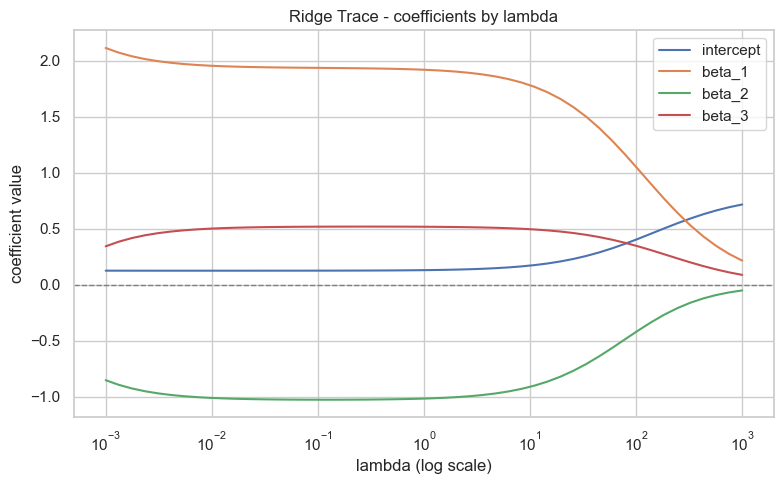

In [8]:
lambdas_grid = make_lambda_grid()

print("--- ĐƯỜNG CONG CO RÚT HỆ SỐ RIDGE REGRESSION ---")
ridge_trace(X_collinear, y_collinear, lambda_grid=lambdas_grid);


## 9. Lựa Chọn Siêu Tham Số Qua K-Fold Cross Validation
### 9.1. Cơ sở lý thuyết

**1. Phương pháp k-Fold Cross-Validation:**
Phương pháp kiểm định chéo $k$-Fold phân tách tập dữ liệu ngẫu nhiên thành $k$ phần bằng nhau độc lập. Mô hình được huấn luyện trên $k-1$ phần và đánh giá hiệu năng (thường dùng MSE) trên phần còn lại. Chu trình lặp lại $k$ lần, sau đó lấy trung bình để tính toán độ sai lệch tổng thể:
$$\text{CV}_{(k)} = \frac{1}{k} \sum_{i=1}^{k} \text{MSE}_i$$
Phương pháp này giúp đánh giá khách quan sức mạnh tổng quát hóa của mô hình, từ đó hỗ trợ tìm ra điểm tối ưu cho các siêu tham số (như $\lambda$ trong Ridge/Lasso) nhằm tránh hiện tượng quá khớp (overfitting).

**2. Tiêu chí lựa chọn mô hình (Model Selection Criteria):**
Bên cạnh Cross-Validation, người ta thường dựa trên các tiêu chí phạt độ phức tạp của mô hình như AIC (Akaike Information Criterion) hoặc BIC (Bayesian Information Criterion) để lựa chọn mô hình tối ưu. Các chỉ số này cân bằng giữa độ khít của dữ liệu (thông qua RSS) và số lượng tham số ($p$):
$$\text{AIC} = n \ln\left(\frac{\text{RSS}}{n}\right) + 2(p + 2)$$
$$\text{BIC} = n \ln\left(\frac{\text{RSS}}{n}\right) + (p + 2) \ln n$$
*(Mô hình có giá trị AIC hoặc BIC càng nhỏ thì càng được ưu tiên lựa chọn).*

### 9.2. Thực nghiệm

--- LỰA CHỌN LAMBDA TỐI ƯU ---


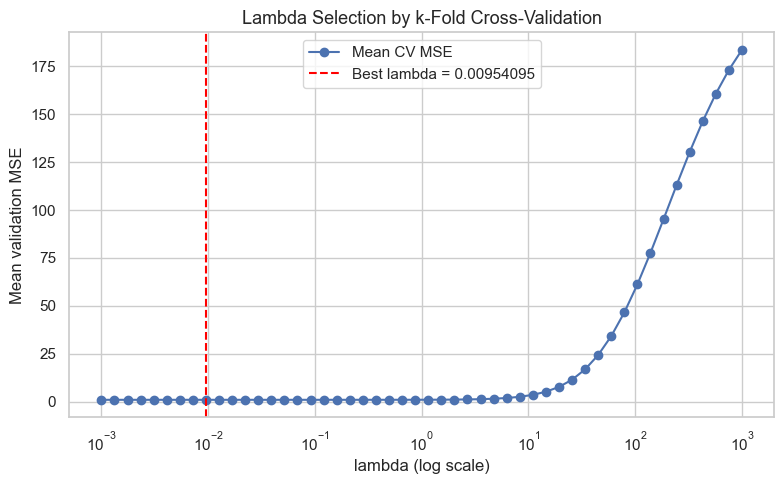


=> Kết quả lựa chọn Hyperparameter tối ưu nhất: λ = 0.0095
=> Giá trị sai số kiểm định (Best Mean CV MSE): 0.906143


In [9]:
print("--- LỰA CHỌN LAMBDA TỐI ƯU ---")
cv_results = select_lambda_cv(
    X=X_collinear, 
    y=y_collinear, 
    k=5, 
    model_fn=ridge_fit,
    lambda_grid=lambdas_grid
)

lambda_opt = cv_results['lambda_opt']
best_mse = cv_results['best_cv_score']

print(f"\n=> Kết quả lựa chọn Hyperparameter tối ưu nhất: λ = {lambda_opt:.4f}")
print(f"=> Giá trị sai số kiểm định (Best Mean CV MSE): {best_mse:.6f}")

### 9.3. So sánh hệ số OLS và Ridge

In [10]:
print(f"\n=> Lambda tối ưu tìm được: {lambda_opt:.4f}")

# Fit mô hình để đối chiếu
X_list = X_collinear.tolist() if hasattr(X_collinear, 'tolist') else X_collinear
y_list = y_collinear.tolist() if hasattr(y_collinear, 'tolist') else y_collinear
res_ols_custom = ols_fit(X_list, y_list)

res_ridge_custom = ridge_fit(X_collinear, y_collinear, lam=lambda_opt)

# Lấy ra bộ trọng số
beta_ols = res_ols_custom['beta_hat']
beta_ridge = res_ridge_custom['beta_hat']

p_len = len(beta_ols)

# Lấy số lượng cột (features) an toàn dù X là List hay Numpy Array
num_features = len(X_collinear[0]) if isinstance(X_collinear, list) else X_collinear.shape[1]
if p_len == num_features + 1:
    idx_names = ['intercept'] + [f'beta_{i}' for i in range(1, p_len)]
else:
    idx_names = [f'beta_{i}' for i in range(1, p_len + 1)]

# Tạo bảng đối chiếu
df_beta_compare = pd.DataFrame({
    'OLS (Tự cài)': beta_ols,
    'Ridge (Tự cài)': beta_ridge
}, index=idx_names)

df_beta_compare['Chênh lệch'] = df_beta_compare['Ridge (Tự cài)'] - df_beta_compare['OLS (Tự cài)']

print("\n--- BẢNG ĐỐI CHIẾU HỆ SỐ BETA (CUSTOM vs CUSTOM) ---")
display(df_beta_compare.style.format("{:.4f}"))


=> Lambda tối ưu tìm được: 0.0095

--- BẢNG ĐỐI CHIẾU HỆ SỐ BETA (CUSTOM vs CUSTOM) ---


,OLS (Tự cài),Ridge (Tự cài),Chênh lệch
intercept,0.1282,0.1246,-0.0036
beta_1,4.4263,1.9554,-2.4708
beta_2,1.4588,-1.0109,-2.4696
beta_3,-1.9707,0.4999,2.4706


## 10. Hồi Quy Lasso & Đồ Thị Co Rút Hệ Số
### 10.1. Cơ sở lý thuyết
Hồi quy Lasso Regression ($L_1$) sử dụng thành phần phạt chuẩn $L_1$ ($\lambda \|\boldsymbol{\beta}\|_1$). Thành phần phạt này tạo ra biên ràng buộc dạng góc nhọn, ép các hệ số của các biến không quan trọng hoặc đa cộng tuyến về chính xác giá trị $0$. Bài toán tối ưu được biểu diễn qua công thức:
$$\hat{\boldsymbol{\beta}}_{\text{lasso}} = \arg \min_{\boldsymbol{\beta}} \left\{ \|\mathbf{y} - \mathbf{X}\boldsymbol{\beta}\|^2 + \lambda \|\boldsymbol{\beta}\|_1 \right\}$$

Khác với Ridge, Lasso không có nghiệm đóng (closed-form solution) phân tích. Thay vào đó, bài toán được giải bằng thuật toán tối ưu hóa tọa độ từng bước (Coordinate Descent) hoặc các phương pháp dưới gradient (subgradient methods) để tạo ra các mô hình có tính thưa (sparsity).

### 10.2. Thực nghiệm

--- ĐƯỜNG CONG CO RÚT HỆ SỐ LASSO REGRESSION (TÍNH THƯA) ---


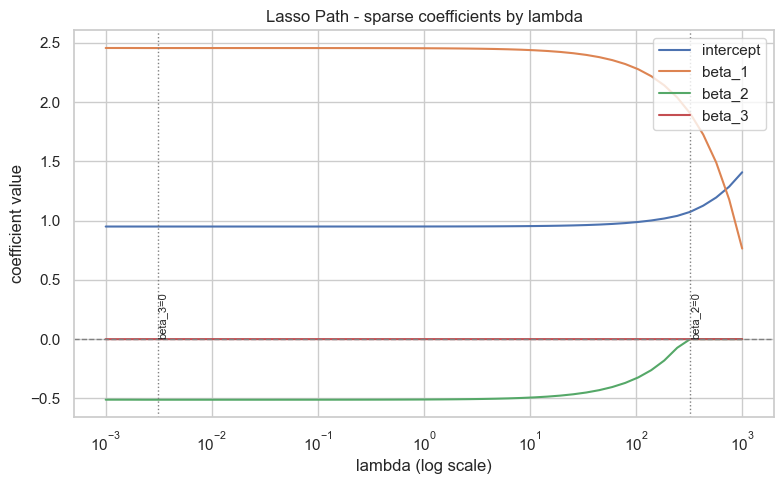

First lambda where coefficients become exactly zero:
  beta_2: 323.746
  beta_3: 0.00308884

--- PHÂN TÍCH TÍNH THƯA (SPARSITY) ---
-> Tại λ ≈ 0.0023, biến [3] bắt đầu bị triệt tiêu.

Các cột mốc thay đổi (Sparsity milestones):
λ ≈ 0.0023: Biến [3] bị triệt tiêu.
λ ≈ 323.7458: Biến [2, 3] bị triệt tiêu.

--- BẢNG HIỆU NĂNG HỘI TỤ (N_ITER) ---


,lambda,n_iter
0,0.0010,1000
10,0.0168,149
20,0.2812,13
30,4.7149,4
40,79.0604,4


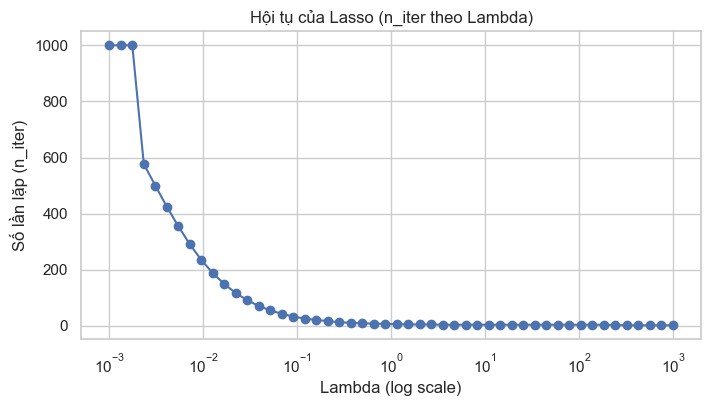

In [11]:
print("--- ĐƯỜNG CONG CO RÚT HỆ SỐ LASSO REGRESSION (TÍNH THƯA) ---")
lasso_trace(X_collinear, y_collinear, lambda_grid=lambdas_grid)
lasso_results = []
zero_tol = 1e-6
for lam in lambdas_grid:
    result = lasso_fit(X_collinear, y_collinear, lam)
    beta = result["beta_hat"][1:]
    lasso_results.append({
        'lambda': lam,
        'coefs': beta,
        'n_iter': result.get('n_iter', np.nan)
    })

print("\n--- PHÂN TÍCH TÍNH THƯA (SPARSITY) ---")
sparsity_report = []
for res in lasso_results:
    lam = res['lambda']
    zero_vars = [
        j + 1
        for j, coef in enumerate(res['coefs'])
        if abs(coef) <= zero_tol
    ]
    if zero_vars:
        sparsity_report.append((lam, zero_vars))
if sparsity_report:
    first_lam, vars_zero = sparsity_report[0]
    print(f"-> Tại λ ≈ {first_lam:.4f}, biến {vars_zero} bắt đầu bị triệt tiêu.\n")
    print("Các cột mốc thay đổi (Sparsity milestones):")
    last_vars = []
    for lam, vars_zero in sparsity_report:
        if vars_zero != last_vars:
            print(f"λ ≈ {lam:.4f}: Biến {vars_zero} bị triệt tiêu.")
            last_vars = vars_zero
else:
    print("Không có biến nào bị triệt tiêu trên lambda grid.")
df_convergence = pd.DataFrame(
    lasso_results
)[['lambda', 'n_iter']]

print("\n--- BẢNG HIỆU NĂNG HỘI TỤ (N_ITER) ---")

display(
    df_convergence.iloc[::10]
    .style
    .format({
        'lambda': '{:.4f}',
        'n_iter': '{:.0f}'
    })
)

plt.figure(figsize=(8, 4))
plt.plot(
    df_convergence['lambda'],
    df_convergence['n_iter'],
    marker='o'
)
plt.xscale('log')
plt.title(
    "Hội tụ của Lasso "
    "(n_iter theo Lambda)"
)
plt.xlabel("Lambda (log scale)")
plt.ylabel("Số lần lặp (n_iter)")
plt.grid(True)
plt.show()

## 11. Minh Họa Định Lý Gauss-Markov Bằng Mô Phỏng Monte Carlo
### 11.1. Cơ sở lý thuyết
Định lý Gauss-Markov phát biểu rằng dưới các giả thiết cơ bản của mô hình hồi quy (GM1–GM4), ước lượng OLS $\hat{\boldsymbol{\beta}}_{\text{OLS}}$ là ước lượng tuyến tính không chệch tốt nhất (BLUE - Best Linear Unbiased Estimator). Cụ thể:

1. **Tính không chệch (Unbiased):** Giá trị kỳ vọng của ước lượng hội tụ chính xác về giá trị thực của tham số tổng thể.
$$\mathbb{E}[\hat{\boldsymbol{\beta}}_{\text{OLS}}] = \boldsymbol{\beta}$$

2. **Tốt nhất / Phương sai nhỏ nhất (Best / Minimum Variance):** Với mọi ước lượng tuyến tính không chệch $\tilde{\boldsymbol{\beta}}$ khác, ước lượng OLS luôn có phương sai nhỏ nhất (độ chính xác cao nhất) cho từng hệ số tương ứng.
$$\text{Var}(\tilde{\beta}_j) \geq \text{Var}(\hat{\beta}_j^{\text{OLS}}) \quad \text{với mọi } j$$

**Ma trận hiệp phương sai của ước lượng OLS:**
Độ phân tán của bộ trọng số OLS được xác định thông qua ma trận hiệp phương sai (covariance matrix), phụ thuộc vào phương sai sai số $\sigma^2$ và ma trận thiết kế $\mathbf{X}$:
$$\text{Var}(\hat{\boldsymbol{\beta}}_{\text{OLS}} \mid \mathbf{X}) = \sigma^2(\mathbf{X}^T\mathbf{X})^{-1}$$

### 11.2. Thực nghiệm

Đang khởi chạy thực nghiệm mô phỏng Monte Carlo 1000 phiên...

--- BẢNG THỐNG KÊ ĐỐI CHỨNG ĐỊNH LÝ GAUSS-MARKOV ---


,True Beta,OLS Expected Mean E[β],Alt Estimator Mean,OLS Variance,Alt Estimator Variance
Intercept (β0),2.0,2.001940,1.990790,0.009855,0.009751
Hệ số x1 (β1),-1.5,-1.497198,-1.487166,0.011864,0.011725
Hệ số x2 (β2),0.8,0.798037,0.795140,0.013046,0.012888


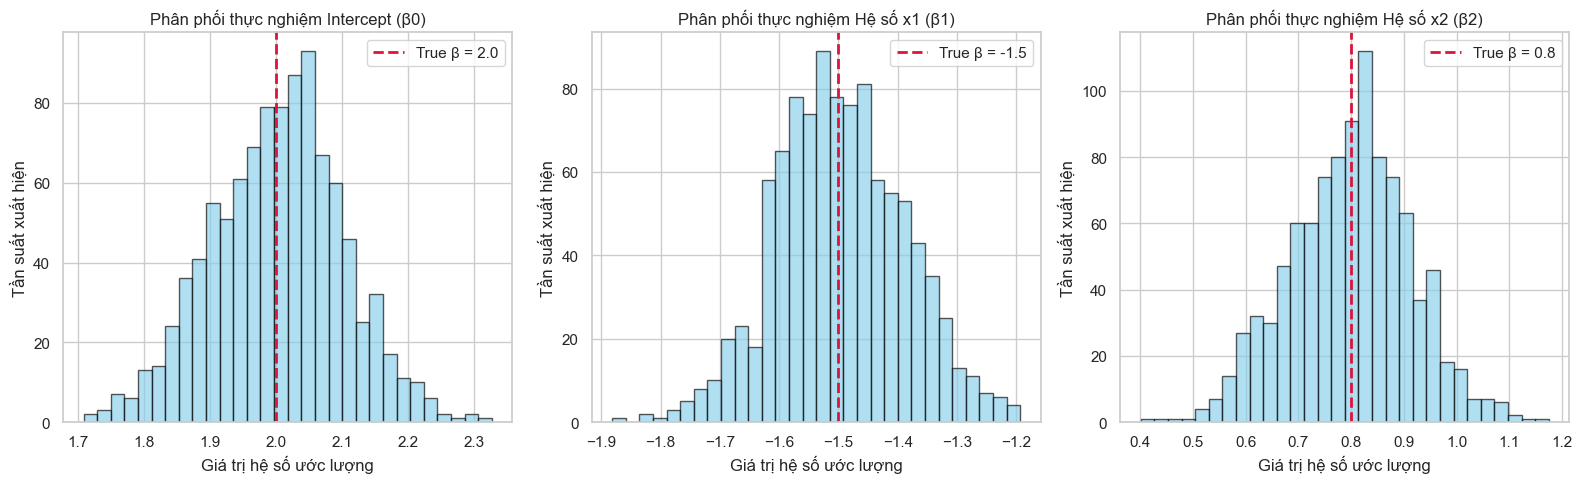

In [12]:
print("Đang khởi chạy thực nghiệm mô phỏng Monte Carlo 1000 phiên...")
N_SIM = 1000
N_OBS = 100
TRUE_BETA = [2.0, -1.5, 0.8]
beta_ols_list, beta_alt_list, true_beta = run_gauss_markov_simulation(n_sim=N_SIM, n_obs=N_OBS, true_beta=TRUE_BETA, true_sigma=1.0)

beta_ols_arr = np.array(beta_ols_list)
beta_alt_arr = np.array(beta_alt_list)

# Tính toán giá trị trung bình kỳ vọng và phương sai thực nghiệm
ols_mean = beta_ols_arr.mean(axis=0)
ols_var = beta_ols_arr.var(axis=0)
alt_mean = beta_alt_arr.mean(axis=0)
alt_var = beta_alt_arr.var(axis=0)

# Thành lập bảng dữ liệu phân tích đối chứng thống kê định lượng
df_gauss_markov = pd.DataFrame({
    'True Beta': true_beta,
    'OLS Expected Mean E[β]': ols_mean,
    'Alt Estimator Mean': alt_mean,
    'OLS Variance': ols_var,
    'Alt Estimator Variance': alt_var
}, index=['Intercept (β0)', 'Hệ số x1 (β1)', 'Hệ số x2 (β2)'])

print("\n--- BẢNG THỐNG KÊ ĐỐI CHỨNG ĐỊNH LÝ GAUSS-MARKOV ---")
display(df_gauss_markov)

# Trực quan hóa phân phối tần suất của các hệ số OLS bằng Histogram
fig, axes_gm = plt.subplots(1, 3, figsize=(16, 5))
labels_title = ['Intercept (β0)', 'Hệ số x1 (β1)', 'Hệ số x2 (β2)']

for i in range(3):
    axes_gm[i].hist(beta_ols_arr[:, i], bins=30, color='skyblue', edgecolor='black', alpha=0.65)
    axes_gm[i].axvline(true_beta[i], color='crimson', linestyle='--', linewidth=2, label=rf'True β = {true_beta[i]}')
    axes_gm[i].set_title(f'Phân phối thực nghiệm {labels_title[i]}')
    axes_gm[i].set_xlabel('Giá trị hệ số ước lượng')
    axes_gm[i].set_ylabel('Tần suất xuất hiện')
    axes_gm[i].legend()

plt.tight_layout()
plt.show()

### 11.3. Nhận xét và Phân tích kết quả mô phỏng
Dựa trên bảng thống kê định lượng và các biểu đồ phân phối tần suất thu được từ 1000 phiên mô phỏng Monte Carlo, ta có các kết luận thực nghiệm quan trọng hoàn toàn nhất quán với lý thuyết toán học:

1. **Tính không chệch (Unbiasedness) của OLS:** Giá trị trung bình thực nghiệm của các hệ số OLS (`OLS Expected Mean E[β]`) hội tụ rất sát về giá trị thực tế `True Beta` ban đầu ($\mathbb{E}[\hat{\boldsymbol{\beta}}_{OLS}] \approx \boldsymbol{\beta}$). Điều này xác nhận OLS là một ước lượng không chệch.

2. **Hiện tượng co rút và Độ chệch của ước lượng thay thế (Ridge):** Ước lượng thay thế (Alt Estimator với thành phần phạt Ridge $\alpha = 0.5$) cho kết quả trung bình thực nghiệm (`Alt Estimator Mean`) bị lệch rõ rệt so với `True Beta`. Điều này minh chứng rằng hồi quy Ridge là một **ước lượng có chệch (biased estimator)**.

3. **Sự đánh đổi Bias - Variance (Bias-Variance Tradeoff):** Mặc dù mang một độ chệch nhất định, phương sai thực nghiệm của ước lượng thay thế (`Alt Estimator Variance` - Ridge) lại **nhỏ hơn** so với phương sai thực nghiệm của OLS (`OLS Variance`). Điều này cho thấy regularization có thể đạt MSE tổng thể thấp hơn OLS bằng cách chấp nhận một lượng bias nhỏ để đổi lấy phương sai nhỏ hơn đáng kể.

4. **Lưu ý học thuật về Định lý Gauss-Markov (BLUE):** Mô phỏng Monte Carlo này thành công trong việc minh họa tính **Không chệch (Unbiased)** của OLS và hiện tượng đánh đổi Bias-Variance của lớp mô hình Regularization. Tuy nhiên, cần lưu ý rằng thí nghiệm này tập trung làm rõ ranh giới của định lý, chứ chưa trực tiếp chứng minh tính **Tốt nhất (Best - Minimum Variance)** của OLS. Để chứng minh thực nghiệm tính "Best", ta cần so sánh OLS với một ước lượng tuyến tính không chệch phụ (sub-optimal unbiased linear estimator). Tính chất "Tốt nhất" này đã được bảo đảm tuyệt đối bằng chứng minh toán học giải tích của Định lý Gauss-Markov.